In [1]:
import pandas as pd

houseprices = pd.read_csv("HousePrices.csv")

houseprices.head(5)

,date,price,bedrooms,bathrooms,sqft_living,floors,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city
0,02-05-2014 00:00,313000.0,3,1.50,1340,1.5,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline
1,02-05-2014 00:00,2384000.0,5,2.50,3650,2.0,4,5,3370,280,1921,0,709 W Blaine St,Seattle
2,02-05-2014 00:00,342000.0,3,2.00,1930,1.0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent
3,02-05-2014 00:00,420000.0,3,2.25,2000,1.0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue
4,02-05-2014 00:00,550000.0,4,2.50,1940,1.0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond


In [2]:
## clean display

pd.options.display.float_format = '{:,.2f}'.format

## Data Inspection

In [3]:
houseprices.shape

(4600, 14)

In [4]:
houseprices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   int64  
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   floors         4600 non-null   float64
 6   view           4600 non-null   int64  
 7   condition      4600 non-null   int64  
 8   sqft_above     4600 non-null   int64  
 9   sqft_basement  4600 non-null   int64  
 10  yr_built       4600 non-null   int64  
 11  yr_renovated   4600 non-null   int64  
 12  street         4600 non-null   object 
 13  city           4600 non-null   object 
dtypes: float64(3), int64(8), object(3)
memory usage: 503.3+ KB


In [5]:
## fix date

houseprices['date'] = pd.to_datetime(
    houseprices['date'],
    errors='coerce',
    dayfirst=True
)

In [6]:
# no broken dates
houseprices['date'].isnull().sum()

np.int64(0)

In [7]:
houseprices.duplicated().sum()

np.int64(0)

In [8]:
houseprices.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
floors           0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
dtype: int64

In [9]:
import numpy as np

houseprices['yr_renovated'] = houseprices['yr_renovated'].replace(0, np.nan)

In [10]:
houseprices['yr_renovated'].isnull().sum()

# 2735 houses : NOT renovated
# the rest: renovated 

np.int64(2735)

## Create the hd DataFrame

In [11]:
hd = houseprices[['date','price','bedrooms','bathrooms',
                  'sqft_living','yr_built','yr_renovated','city']].copy()

In [12]:
# to create a new column
hd['renovated'] = hd['yr_renovated'].notnull()
hd.head()

,date,price,bedrooms,bathrooms,sqft_living,yr_built,yr_renovated,city,renovated
0,2014-05-02,"313,000.00",3,1.50,1340,1955,"2,005.00",Shoreline,True
1,2014-05-02,"2,384,000.00",5,2.50,3650,1921,NaN,Seattle,False
2,2014-05-02,"342,000.00",3,2.00,1930,1966,NaN,Kent,False
3,2014-05-02,"420,000.00",3,2.25,2000,1963,NaN,Bellevue,False
4,2014-05-02,"550,000.00",4,2.50,1940,1976,"1,992.00",Redmond,True


## SQLite - Connect & Send DataFrame to SQL & Query

In [13]:
import sqlite3

conn = sqlite3.connect("SQL_Challenges.db")

In [14]:
hd.to_sql("house_data", conn, if_exists='replace', index=False)

4600

In [15]:
query = "SELECT * FROM house_data WHERE city = 'Seattle'"
seattle_df = pd.read_sql(query, conn)

seattle_df.head()

,date,price,bedrooms,bathrooms,sqft_living,yr_built,yr_renovated,city,renovated
0,2014-05-02 00:00:00,"2,384,000.00",5,2.50,3650,1921,NaN,Seattle,0
1,2014-05-02 00:00:00,"490,000.00",2,1.00,880,1938,"1,994.00",Seattle,1
2,2014-05-02 00:00:00,"640,000.00",4,2.00,1520,1945,"2,010.00",Seattle,1
3,2014-05-02 00:00:00,"1,400,000.00",4,2.50,2920,1909,"1,988.00",Seattle,1
4,2014-05-02 00:00:00,"365,000.00",3,1.00,1090,1955,"2,009.00",Seattle,1


## Analysis

In [16]:
## Sales per city
city_summary = hd.groupby('city')['price'].agg(['count','sum','mean'])
city_summary.head()

,count,sum,mean
city,,,
Algona,5,"1,036,440.00","207,288.00"
Auburn,176,"52,683,917.93","299,340.44"
Beaux Arts Village,1,"745,000.00","745,000.00"
Bellevue,286,"242,293,669.62","847,180.66"
Black Diamond,9,"3,056,450.00","339,605.56"


In [17]:
## Price category added
def category(x):
    if x < 1000000:
        return 'Low Price'
    elif x <= 25000000:
        return 'Average Price'
    else:
        return 'Luxury Price'

hd['price_category'] = hd['price'].apply(category)
hd.head()

,date,price,bedrooms,bathrooms,sqft_living,yr_built,yr_renovated,city,renovated,price_category
0,2014-05-02,"313,000.00",3,1.50,1340,1955,"2,005.00",Shoreline,True,Low Price
1,2014-05-02,"2,384,000.00",5,2.50,3650,1921,NaN,Seattle,False,Average Price
2,2014-05-02,"342,000.00",3,2.00,1930,1966,NaN,Kent,False,Low Price
3,2014-05-02,"420,000.00",3,2.25,2000,1963,NaN,Bellevue,False,Low Price
4,2014-05-02,"550,000.00",4,2.50,1940,1976,"1,992.00",Redmond,True,Low Price


In [18]:
## Month columns created
hd['month'] = hd['date'].dt.month
hd['month_year'] = hd['date'].dt.to_period('M')
hd.head()

,date,price,bedrooms,bathrooms,sqft_living,yr_built,yr_renovated,city,renovated,price_category,month,month_year
0,2014-05-02,"313,000.00",3,1.50,1340,1955,"2,005.00",Shoreline,True,Low Price,5,2014-05
1,2014-05-02,"2,384,000.00",5,2.50,3650,1921,NaN,Seattle,False,Average Price,5,2014-05
2,2014-05-02,"342,000.00",3,2.00,1930,1966,NaN,Kent,False,Low Price,5,2014-05
3,2014-05-02,"420,000.00",3,2.25,2000,1963,NaN,Bellevue,False,Low Price,5,2014-05
4,2014-05-02,"550,000.00",4,2.50,1940,1976,"1,992.00",Redmond,True,Low Price,5,2014-05


In [19]:
## Monthly sales
monthly = hd.groupby('month')['price'].agg(['sum','median'])
monthly

,sum,median
month,,
5,"943,798,777.17","458,950.00"
6,"1,194,022,664.02","455,000.00"
7,"401,208,305.78","487,000.00"


In [20]:
## Top 5 months by median price
monthly.sort_values(by='median', ascending=False).head(5)

,sum,median
month,,
7,"401,208,305.78","487,000.00"
5,"943,798,777.17","458,950.00"
6,"1,194,022,664.02","455,000.00"


## Visualization

<Axes: xlabel='sqft_living', ylabel='price'>

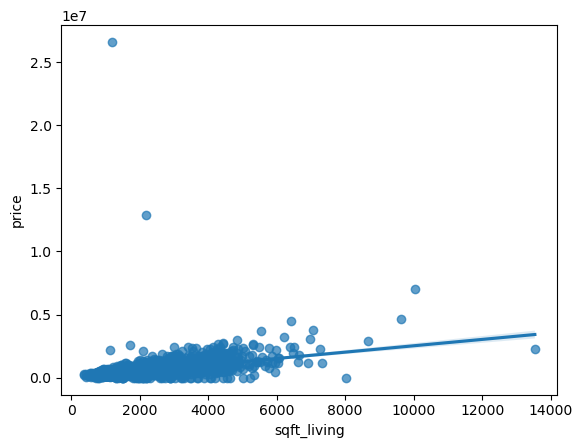

In [28]:
## Scatter with regression line
import seaborn as sns

sns.regplot(data=hd, x='sqft_living', y='price', scatter_kws={'alpha':0.7})

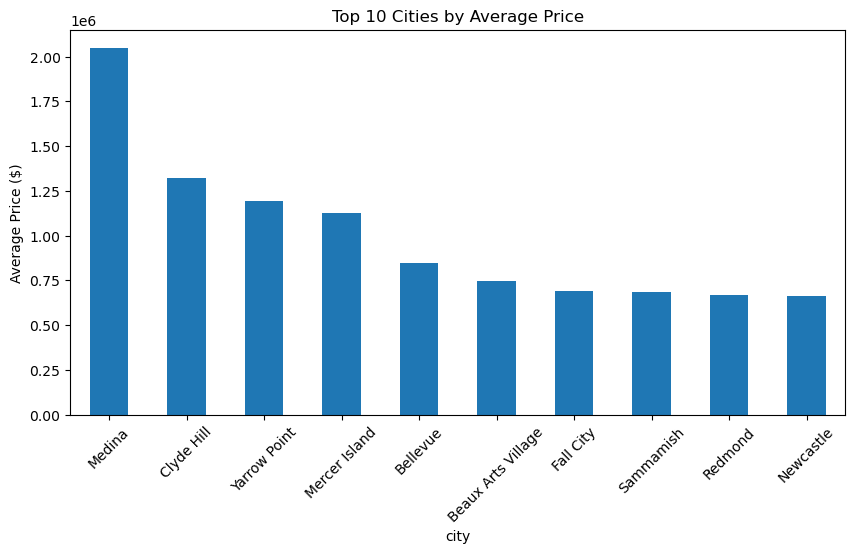

In [33]:
## Bar chart for only TOP 10 cities
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
top10['mean'].plot(kind='bar')
plt.title("Top 10 Cities by Average Price")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.show()

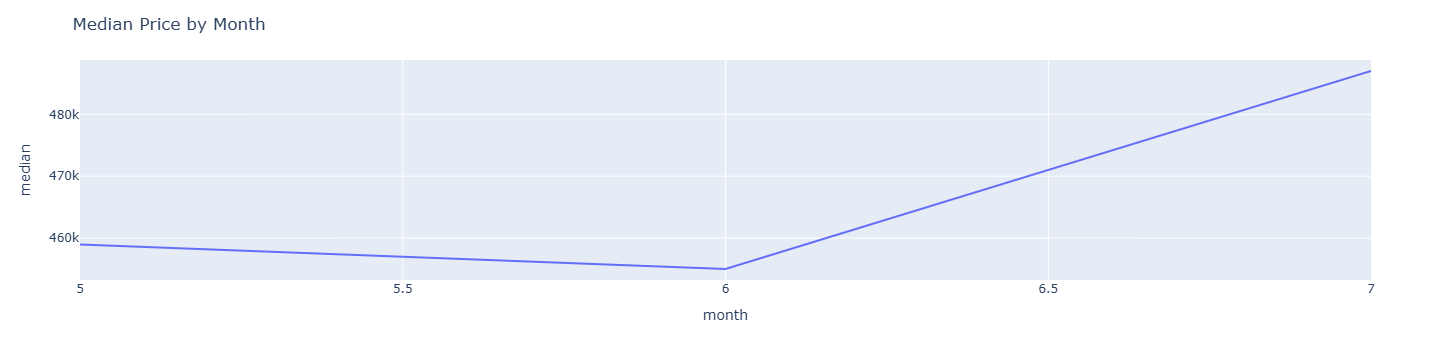

In [36]:
## Line graph for median price by month
import plotly.express as px

fig = px.line(monthly.reset_index(), x='month', y='median')
fig.update_layout(title="Median Price by Month")
fig.show()

# Month 7 has the highest median price, followed by Month 5 and Month 6. This suggests that housing prices slightly increase toward mid-year.

## Conclusion


This analysis shows that house prices are influenced by location and size. 
Cities like Medina, Clyde Hill, and Yarrow Point have the highest average prices.
    
The scatterplot shows a positive relationship between square footage and price, 
meaning larger houses tend to be more expensive.

The monthly analysis shows that prices are slightly higher in Month 7 compared to other months, 
suggesting a possible seasonal trend.

Overall, the data provides useful insights into the housing market and can help support decision-making.